<a href="https://colab.research.google.com/github/Chaerrysun/Alice-in-Wonderland-Analysis/blob/main/Alice_In_Wonderland_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a name="top"></a>

# Linguistic Analysis of Alice's Adventures in Wonderland

## Table of Contents

1. Introduction
2. Data Collection
3. Text Preprocessing
4. Corpus Statistics
5. Frequency Analysis
6. Character Analysis
7. Word Cloud
8. Part-of-Speech Analysis
9. Bigram Analysis
10. Sentiment Analysis
11. Conclusion


## Introduction

Natural Language Processing (NLP) is a field of computer science and linguistics that focuses on enabling computers to understand and analyse human language. This project investigates the linguistic characteristics of Lewis Carroll's *Alice's Adventures in Wonderland* using Python.

The text is collected directly from Project Gutenberg through web scraping with BeautifulSoup and analysed using the Natural Language Toolkit (NLTK). The objectives of this study are:

- To collect textual data from a website
- To preprocess and clean the text
- To examine vocabulary richness
- To identify frequent words and collocations
- To analyse grammatical patterns
- To visualise linguistic features

The analysis demonstrates how computational methods can support traditional literary and linguistic research.

In [ ]:
!pip install nltk beautifulsoup4 requests wordcloud ipywidgets -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 89.4 MB/s eta 0:00:00


In [ ]:
import requests
from bs4 import BeautifulSoup

import nltk
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('vader_lexicon')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

# Data Collection

The text used in this analysis is obtained from Project Gutenberg. BeautifulSoup is used to extract the textual content from the HTML document.

In [ ]:
url = "https://www.gutenberg.org/cache/epub/11/pg11-images.html"

response = requests.get(url)

print("Status Code:", response.status_code)

soup = BeautifulSoup(response.text, "html.parser")

text = soup.get_text(separator=" ")

print(text[:1000])

Status Code: 200

 
 
 Alice’s Adventures in Wonderland | Project Gutenberg 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 The Project Gutenberg eBook of  Alice's Adventures in Wonderland 
 This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online
at  www.gutenberg.org . If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBook. 
 Title : Alice's Adventures in Wonderland 
 
 Author : Lewis Carroll 
 
 
 Release date : June 27, 2008 [eBook #11] 
                Most recently updated: June 26, 2025 
 Language : English 
 Other information and formats :  www.gutenberg.org/ebooks/11 
 Credits : Arthur DiBianca and David Widger 
 
 *** START OF THE PROJECT GUTENBERG EBOOK ALICE'S ADVENTURES 

# Text Preprocessing

The raw text contains punctuation, numbers, and formatting artefacts. These must be removed before meaningful linguistic analysis can be performed.

In [ ]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

import nltk
nltk.download('punkt_tab')

tokens = word_tokenize(text.lower())

words = [
    word for word in tokens
    if word.isalpha()
]

stop_words = set(stopwords.words('english'))

filtered_words = [
    word for word in words
    if word not in stop_words
]

print("Total words:", len(words))
print("Filtered words:", len(filtered_words))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Total words: 29539
Filtered words: 13334


# Corpus Statistics

Several basic corpus statistics are calculated to understand the size and richness of the vocabulary.

In [ ]:
total_words = len(filtered_words)

unique_words = len(set(filtered_words))

lexical_diversity = unique_words / total_words

avg_word_length = sum(len(word) for word in filtered_words) / total_words

print("Total Words:", total_words)
print("Unique Words:", unique_words)
print("Lexical Diversity:", round(lexical_diversity,4))
print("Average Word Length:", round(avg_word_length,2))

Total Words: 13334
Unique Words: 2732
Lexical Diversity: 0.2049
Average Word Length: 5.56


## Discussion

Lexical diversity measures how varied the vocabulary of a text is. A higher value indicates a wider range of vocabulary. Literary works often display greater lexical diversity than everyday speech because authors intentionally employ varied language for stylistic purposes.

# Frequency Analysis

Word frequency is one of the most fundamental techniques in corpus linguistics. It reveals which concepts and themes dominate a text.

In [ ]:
from nltk import FreqDist

fdist = FreqDist(filtered_words)

top20 = fdist.most_common(20)

pd.DataFrame(top20, columns=["Word","Frequency"])

,Word,Frequency
0,said,459
1,alice,404
2,little,129
3,one,103
4,project,89
5,like,84
6,would,83
7,went,83
8,could,78
9,queen,76


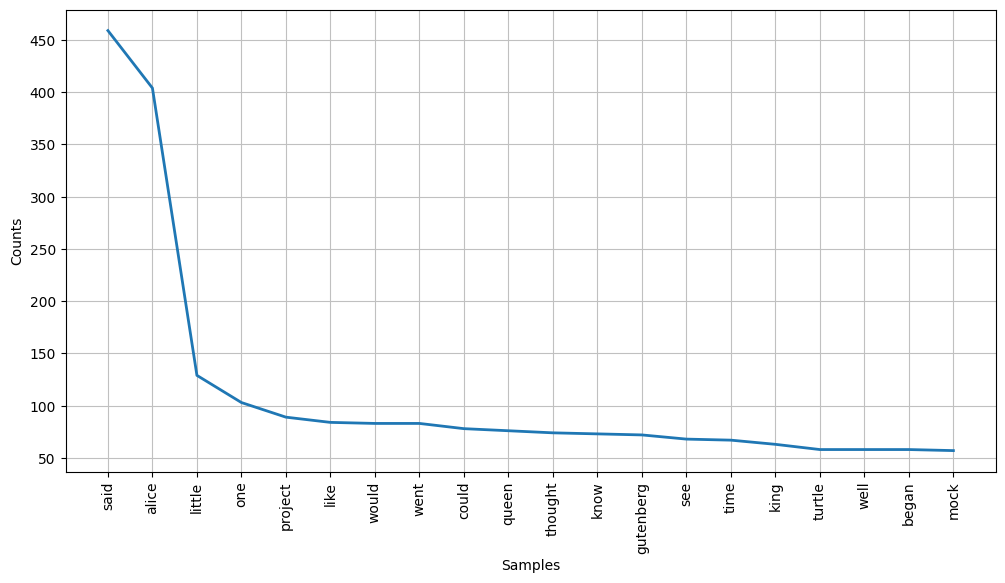

In [ ]:
plt.figure(figsize=(12,6))

fdist.plot(20)

plt.show()

## Interpretation

The most frequent words provide insight into recurring themes and important characters within the novel. Frequent occurrence often reflects narrative focus.

# Character Frequency Analysis

Since *Alice's Adventures in Wonderland* contains several prominent characters, analysing their frequency can reveal which figures are most central to the narrative.

In [ ]:
characters = [
    "alice",
    "rabbit",
    "queen",
    "king",
    "mouse",
    "hatter",
    "duchess",
    "cat"
]

character_counts = {
    character: filtered_words.count(character)
    for character in characters
}

character_counts

{'alice': 404,
 'rabbit': 48,
 'queen': 76,
 'king': 63,
 'mouse': 39,
 'hatter': 55,
 'duchess': 42,
 'cat': 37}

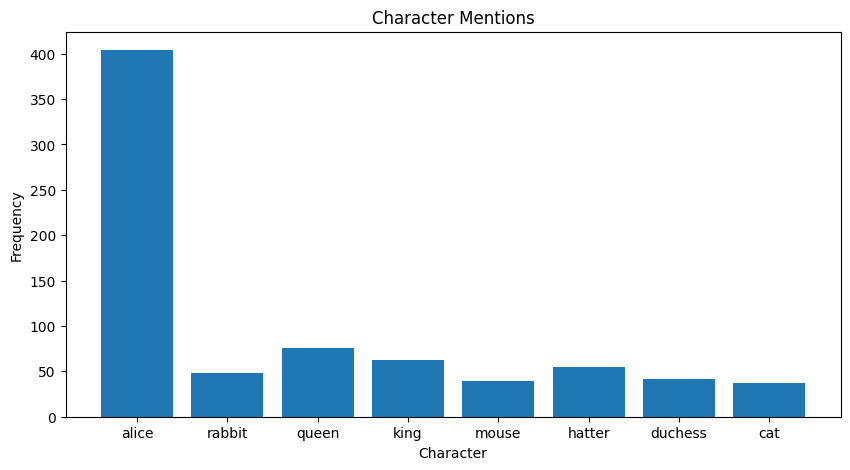

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(
    character_counts.keys(),
    character_counts.values()
)

plt.title("Character Mentions")
plt.xlabel("Character")
plt.ylabel("Frequency")

plt.show()

## Interpretation

Alice is expected to dominate the text because she is the protagonist. Other highly frequent characters indicate their importance to the plot and thematic development.

# Word Cloud

A word cloud provides a visual representation of word frequency. Larger words appear more often within the corpus.

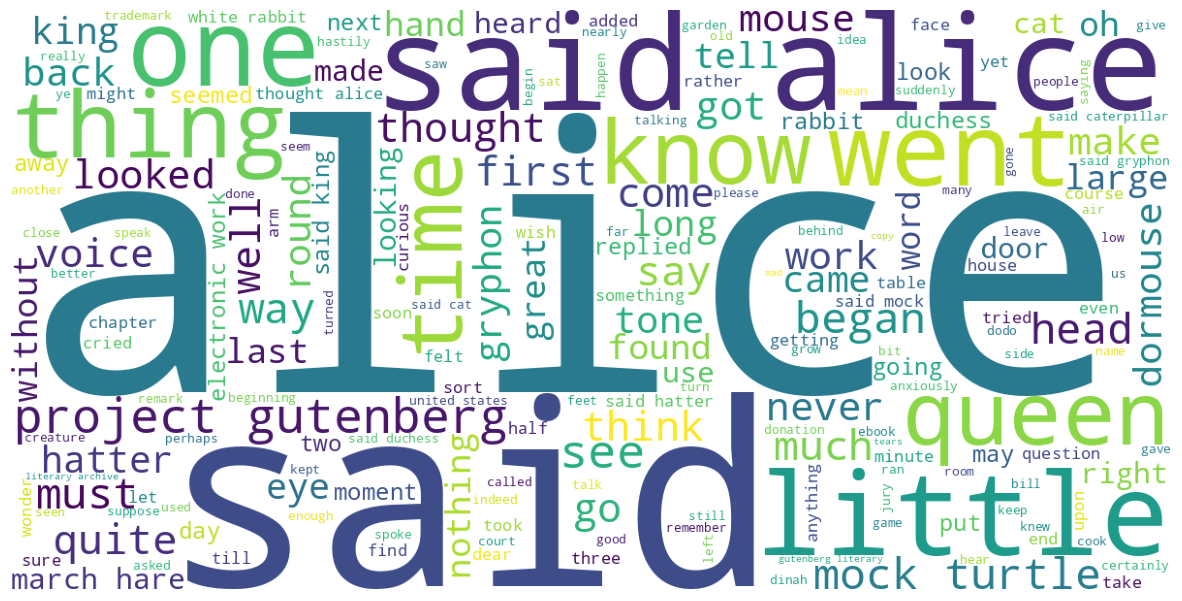

In [ ]:
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(" ".join(filtered_words))

plt.figure(figsize=(15,8))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

# Part-of-Speech Analysis

Part-of-speech tagging identifies the grammatical role of words. This helps reveal stylistic characteristics of the text.

In [ ]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

tagged_words = nltk.pos_tag(filtered_words)

pos_counts = Counter(
    tag for word, tag in tagged_words
)

pos_counts.most_common(10)

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


[('NN', 4110),
 ('JJ', 2380),
 ('VBD', 1538),
 ('RB', 1184),
 ('NNS', 886),
 ('VBG', 698),
 ('VB', 474),
 ('VBP', 465),
 ('VBN', 447),
 ('MD', 313)]

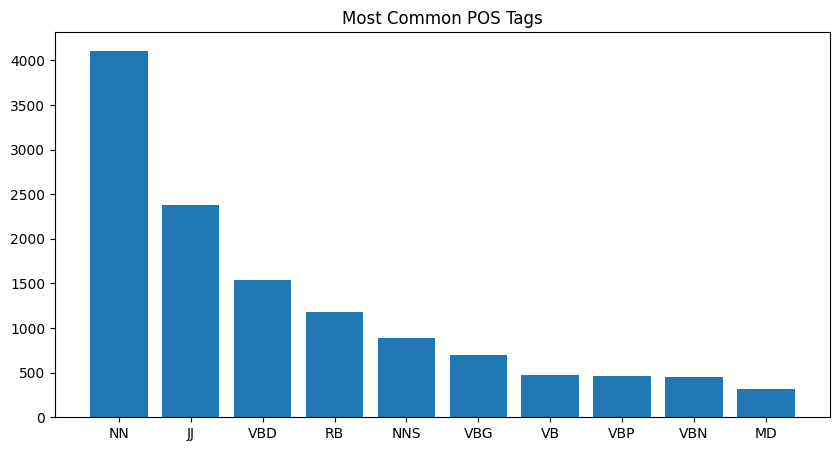

In [ ]:
top_pos = pos_counts.most_common(10)

labels = [x[0] for x in top_pos]
values = [x[1] for x in top_pos]

plt.figure(figsize=(10,5))
plt.bar(labels, values)

plt.title("Most Common POS Tags")

plt.show()

## Interpretation

Nouns frequently dominate literary texts because they refer to characters, objects and locations. Verbs indicate actions while adjectives contribute descriptive detail.

# Bigram Analysis

Bigrams are pairs of consecutive words. They help identify recurring expressions and collocations.

In [ ]:
from nltk import bigrams

bigram_list = list(bigrams(filtered_words))

bigram_freq = Counter(bigram_list)

top_bigrams = bigram_freq.most_common(15)

pd.DataFrame(
    top_bigrams,
    columns=["Bigram","Frequency"]
)

,Bigram,Frequency
0,"(said, alice)",123
1,"(project, gutenberg)",72
2,"(mock, turtle)",57
3,"(march, hare)",31
4,"(said, king)",29
5,"(thought, alice)",26
6,"(white, rabbit)",22
7,"(said, hatter)",21
8,"(said, mock)",20
9,"(said, caterpillar)",18


# Sentiment Analysis

Sentiment analysis estimates the emotional tone of a text. Although literary works contain mixed emotions, sentiment scores provide a useful overview.

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

scores = sia.polarity_scores(text)

scores

{'neg': 0.084, 'neu': 0.821, 'pos': 0.096, 'compound': 0.9999}

## Interpretation

The sentiment scores indicate the overall emotional balance of the novel. Since *Alice's Adventures in Wonderland* combines curiosity, absurdity and humour, the sentiment is expected to be relatively neutral with slight positive tendencies.

# Conclusion

This project demonstrated how web scraping and natural language processing techniques can be combined to analyse literary texts.

Using BeautifulSoup, the text of *Alice's Adventures in Wonderland* was collected from Project Gutenberg. NLTK was then used to perform tokenisation, stopword removal, frequency analysis, part-of-speech tagging, bigram extraction and sentiment analysis.

The results revealed patterns in vocabulary usage, character prominence and grammatical structure. These findings illustrate the value of computational methods for linguistic and literary research.

Future work could include named entity recognition, topic modelling, readability analysis and comparisons with other literary works.